In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Percorso base relativo al progetto
base_path = Path("dati/streaming_row")
import pandas as pd
from pathlib import Path

# Percorso base relativo al progetto
base_path = Path("dati/streaming_row")

# Controlla se il percorso esiste
if not base_path.exists():
    print(f"Errore: Il percorso '{base_path}' non esiste!")

# Trova tutti i file dati_mqtt_realtime.csv nelle sottocartelle
real_time_files = list(base_path.rglob("dati_mqtt_realtime.csv"))  # Cerca ricorsivamente

# Debug: stampiamo i file trovati
print(f"File trovati: {real_time_files}")

df_list = []
# Trova tutti i file dati_mqtt_realtime.csv nelle sottocartelle
real_time_files = list(base_path.glob("*/dati_mqtt_realtime.csv"))

df_list = []

File trovati: [WindowsPath('dati/streaming_row/051224/dati_mqtt_realtime.csv'), WindowsPath('dati/streaming_row/200125/dati_mqtt_realtime.csv'), WindowsPath('dati/streaming_row/241024/dati_mqtt_realtime.csv')]


In [3]:
# Lettura e preprocessing di ciascun file CSV
for csv_file in real_time_files:
    print(f"Leggendo: {csv_file}")  # Debug per vedere i file letti
    temp_df = pd.read_csv(csv_file)

    # Controllo se la colonna 'Timestamp' esiste
    if 'Timestamp' not in temp_df.columns:
        print(f"Il file {csv_file} non ha header. Riprovo con header=None ...")
        temp_df = pd.read_csv(csv_file, header=None, names=['Topic', 'Valore', 'Timestamp'])

    if 'Timestamp' not in temp_df.columns:
        print(f"Il file {csv_file} non contiene la colonna 'Timestamp'. Salto il file.")
        continue

    # Conversione della colonna Timestamp in formato datetime
    temp_df['Timestamp'] = pd.to_datetime(temp_df['Timestamp'], format="%a %b %d %H:%M:%S %Y", errors='coerce')

    # Rimozione delle righe con Timestamp non valido
    temp_df.dropna(subset=['Timestamp'], inplace=True)

    # Aggiunta del dataframe alla lista
    if not temp_df.empty:
        df_list.append(temp_df)

Leggendo: dati\streaming_row\051224\dati_mqtt_realtime.csv
Leggendo: dati\streaming_row\200125\dati_mqtt_realtime.csv
Il file dati\streaming_row\200125\dati_mqtt_realtime.csv non ha header. Riprovo con header=None ...
Leggendo: dati\streaming_row\241024\dati_mqtt_realtime.csv


In [4]:
# Unione di tutti i DataFrame
if df_list:
    df = pd.concat(df_list, ignore_index=True)

    # Rimozione duplicati (caso di sovrapposizione dati)
    df.drop_duplicates(subset=['Timestamp', 'Topic'], keep='first', inplace=True)

    # Trasformazione dei dati per ottenere un formato time series con pivot
    df_ts = df.pivot(index='Timestamp', columns='Topic', values='Valore')

    # Ordinamento temporale
    df_ts.sort_index(inplace=True)

    # Interpolazione per riempire eventuali buchi nei dati
    df_ts = df_ts.resample('1s').interpolate()

    # Visualizza le prime righe
    print(df_ts.head())
else:
    print("Nessun file valido trovato.")

Topic                bonfi/gb1_p3_acc_cfa  bonfi/gb1_p3_acc_kurt  \
Timestamp                                                          
2024-10-24 11:18:21                   NaN                    NaN   
2024-10-24 11:18:22              3.700691              -0.169714   
2024-10-24 11:18:23              3.917546              -0.081498   
2024-10-24 11:18:24              4.134402               0.006717   
2024-10-24 11:18:25              3.758840              -0.034362   

Topic                bonfi/gb1_p3_acc_max  bonfi/gb1_p3_acc_min  \
Timestamp                                                         
2024-10-24 11:18:21                   NaN                   NaN   
2024-10-24 11:18:22                   NaN                   NaN   
2024-10-24 11:18:23              0.853956             -0.689925   
2024-10-24 11:18:24              0.904114             -0.723305   
2024-10-24 11:18:25              0.954271             -0.756685   

Topic                bonfi/gb1_p3_acc_rms  bonfi/gb1_

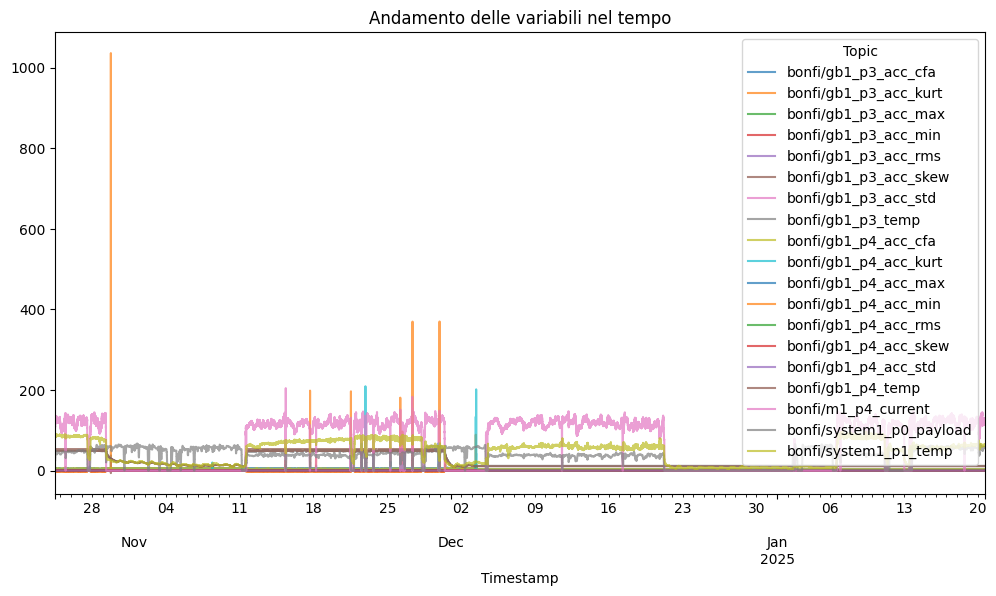

In [20]:
df_ts.plot(figsize=(12,6), alpha=0.7)
plt.title("Andamento delle variabili nel tempo")
plt.show()

In [5]:
# Trova gli indici dei NaN per ogni colonna
nan_positions = df_ts[df_ts.isna().any(axis=1)]  # Seleziona solo le righe con almeno un NaN

# Stampa le prime righe con NaN
nan_positions

Topic,bonfi/gb1_p3_acc_cfa,bonfi/gb1_p3_acc_kurt,bonfi/gb1_p3_acc_max,bonfi/gb1_p3_acc_min,bonfi/gb1_p3_acc_rms,bonfi/gb1_p3_acc_skew,bonfi/gb1_p3_acc_std,bonfi/gb1_p3_temp,bonfi/gb1_p4_acc_cfa,bonfi/gb1_p4_acc_kurt,bonfi/gb1_p4_acc_max,bonfi/gb1_p4_acc_min,bonfi/gb1_p4_acc_rms,bonfi/gb1_p4_acc_skew,bonfi/gb1_p4_acc_std,bonfi/gb1_p4_temp,bonfi/m1_p4_current,bonfi/system1_p0_payload,bonfi/system1_p1_temp
Timestamp,,,,,,,,,,,,,,,,,,,
2024-10-24 11:18:21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.399808,0.008381,1.148129,-1.251302,0.338097,-0.083490,0.337891,52.5,NaN,NaN,NaN
2024-10-24 11:18:22,3.700691,-0.169714,NaN,NaN,0.230825,0.126804,NaN,49.75,3.435140,-0.011886,1.168365,-1.275277,0.340077,-0.108389,0.339844,52.5,128.571442,39.433151,86.344536


In [6]:
for col in df_ts.columns:
    nan_indices = np.where(df_ts[col].isna())[0]  # Indici numerici con NaN
    if len(nan_indices) > 0:
        print(f"Colonna '{col}' ha NaN alle righe: {nan_indices}")

Colonna 'bonfi/gb1_p3_acc_cfa' ha NaN alle righe: [0]
Colonna 'bonfi/gb1_p3_acc_kurt' ha NaN alle righe: [0]
Colonna 'bonfi/gb1_p3_acc_max' ha NaN alle righe: [0 1]
Colonna 'bonfi/gb1_p3_acc_min' ha NaN alle righe: [0 1]
Colonna 'bonfi/gb1_p3_acc_rms' ha NaN alle righe: [0]
Colonna 'bonfi/gb1_p3_acc_skew' ha NaN alle righe: [0]
Colonna 'bonfi/gb1_p3_acc_std' ha NaN alle righe: [0 1]
Colonna 'bonfi/gb1_p3_temp' ha NaN alle righe: [0]
Colonna 'bonfi/m1_p4_current' ha NaN alle righe: [0]
Colonna 'bonfi/system1_p0_payload' ha NaN alle righe: [0]
Colonna 'bonfi/system1_p1_temp' ha NaN alle righe: [0]


In [7]:
print(df_ts.isna().sum())

Topic
bonfi/gb1_p3_acc_cfa        1
bonfi/gb1_p3_acc_kurt       1
bonfi/gb1_p3_acc_max        2
bonfi/gb1_p3_acc_min        2
bonfi/gb1_p3_acc_rms        1
bonfi/gb1_p3_acc_skew       1
bonfi/gb1_p3_acc_std        2
bonfi/gb1_p3_temp           1
bonfi/gb1_p4_acc_cfa        0
bonfi/gb1_p4_acc_kurt       0
bonfi/gb1_p4_acc_max        0
bonfi/gb1_p4_acc_min        0
bonfi/gb1_p4_acc_rms        0
bonfi/gb1_p4_acc_skew       0
bonfi/gb1_p4_acc_std        0
bonfi/gb1_p4_temp           0
bonfi/m1_p4_current         1
bonfi/system1_p0_payload    1
bonfi/system1_p1_temp       1
dtype: int64


In [8]:
df_ts = df_ts.dropna()

In [13]:
threshold_current = 70
threshold_vibration = 0.15
threshold_temp = 30  # Alza pure a 12 o 15 se vuoi

df_ts = df_ts.copy()

# "Off" se (corrente < soglia) AND (vibrazione < soglia) AND (temperatura < soglia)
condition_off = (
    (df_ts['bonfi/m1_p4_current'] < threshold_current) &
    (df_ts['bonfi/gb1_p3_acc_rms'] < threshold_vibration) &
    (df_ts['bonfi/gb1_p3_temp'] < threshold_temp) &
    (df_ts['bonfi/gb1_p4_acc_rms'] < threshold_temp)
)

# "On" = tutto il resto
df_ts.loc[:, 'operational_status'] = (~condition_off).astype(int)

# Controlla quanti sono on/off
print(df_ts['operational_status'].value_counts())

operational_status
1    4706752
0    2913361
Name: count, dtype: int64


C:\Users\OrsoPeruzzi\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


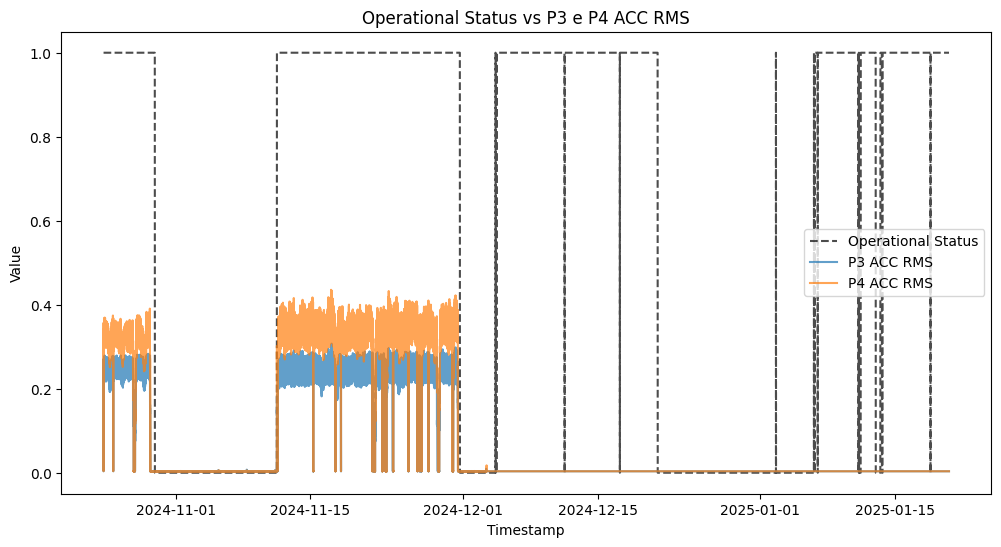

In [14]:
import matplotlib.pyplot as plt

# Selezioniamo solo le colonne richieste
df_plot = df_ts[['operational_status', 'bonfi/gb1_p3_acc_rms', 'bonfi/gb1_p4_acc_rms']]

# Creiamo il grafico
plt.figure(figsize=(12,6))

plt.plot(df_plot.index, df_plot['operational_status'], label="Operational Status", color="black", alpha=0.7, linestyle="dashed")
plt.plot(df_plot.index, df_plot['bonfi/gb1_p3_acc_rms'], label="P3 ACC RMS", alpha=0.7)
plt.plot(df_plot.index, df_plot['bonfi/gb1_p4_acc_rms'], label="P4 ACC RMS", alpha=0.7)

plt.legend()
plt.title("Operational Status vs P3 e P4 ACC RMS")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.show()


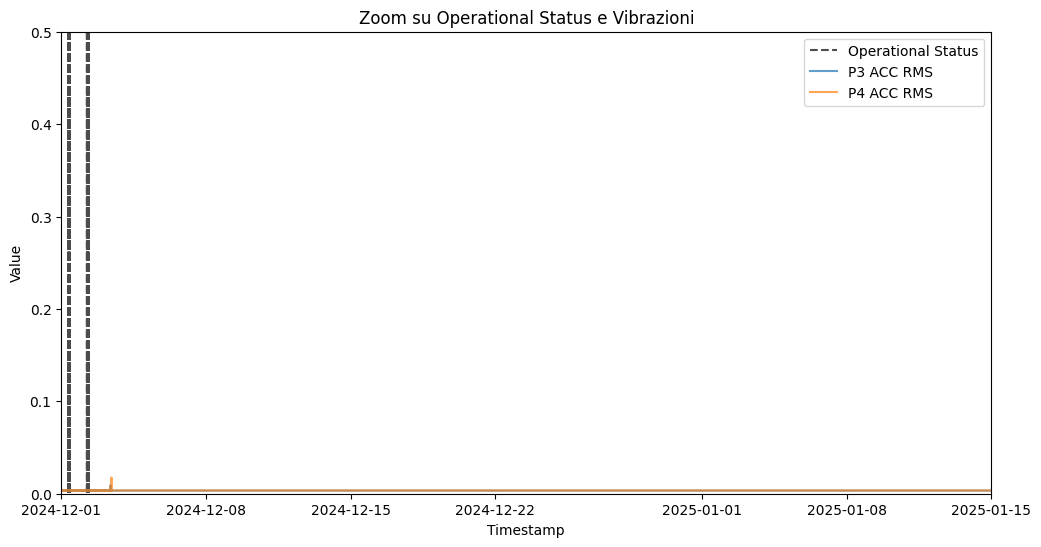

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot delle variabili
plt.plot(df_ts.index, df_ts['operational_status'], label="Operational Status", color="black", linestyle="dashed", alpha=0.7)
plt.plot(df_ts.index, df_ts['bonfi/gb1_p3_acc_rms'], label="P3 ACC RMS", alpha=0.7)
plt.plot(df_ts.index, df_ts['bonfi/gb1_p4_acc_rms'], label="P4 ACC RMS", alpha=0.7)

# Imposta il range temporale per lo zoom
plt.xlim(pd.Timestamp("2024-12-01"), pd.Timestamp("2025-01-15"))  # Modifica le date come necessario

# Imposta un range sui valori dell'asse Y
plt.ylim(0, 0.5)  # Modifica se necessario

plt.legend()
plt.title("Zoom su Operational Status e Vibrazioni")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.show()


In [21]:
# Calcolo degli intervalli minimi e massimi per temperatura, corrente e vibrazioni

# Intervalli di temperatura
temp_min = df_ts[['bonfi/gb1_p3_temp', 'bonfi/gb1_p4_temp']].min()
temp_max = df_ts[['bonfi/gb1_p3_temp', 'bonfi/gb1_p4_temp']].max()

# Intervalli di corrente
current_min = df_ts['bonfi/m1_p4_current'].min()
current_max = df_ts['bonfi/m1_p4_current'].max()

# Intervalli di vibrazione
vibration_min = df_ts[['bonfi/gb1_p3_acc_rms', 'bonfi/gb1_p4_acc_rms']].min()
vibration_max = df_ts[['bonfi/gb1_p3_acc_rms', 'bonfi/gb1_p4_acc_rms']].max()

# Stampa dei risultati
print("Intervalli di Temperatura (P3 e P4):")
print(temp_min, temp_max)
print("\nIntervallo di Corrente:")
print(current_min, current_max)
print("\nIntervalli di Vibrazione (P3 e P4):")
print(vibration_min, vibration_max)

Intervalli di Temperatura (P3 e P4):
Topic
bonfi/gb1_p3_temp    9.50
bonfi/gb1_p4_temp    9.25
dtype: float64 Topic
bonfi/gb1_p3_temp    51.75
bonfi/gb1_p4_temp    54.50
dtype: float64

Intervallo di Corrente:
3.337937145958504e-17 204.78152465820312

Intervalli di Vibrazione (P3 e P4):
Topic
bonfi/gb1_p3_acc_rms    0.003161
bonfi/gb1_p4_acc_rms    0.003318
dtype: float64 Topic
bonfi/gb1_p3_acc_rms    0.307233
bonfi/gb1_p4_acc_rms    0.435544
dtype: float64
